(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

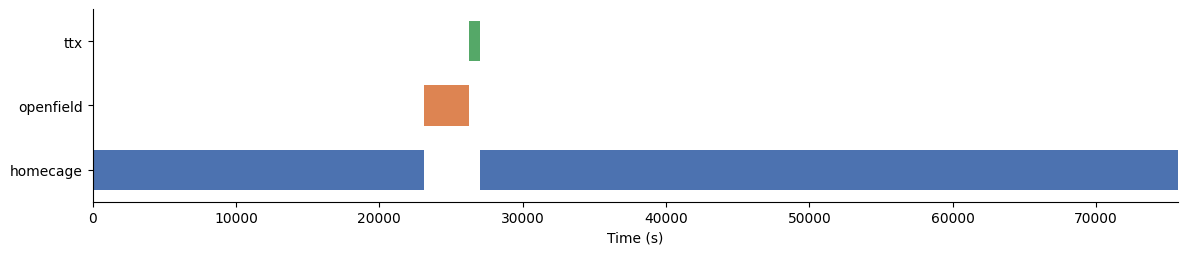

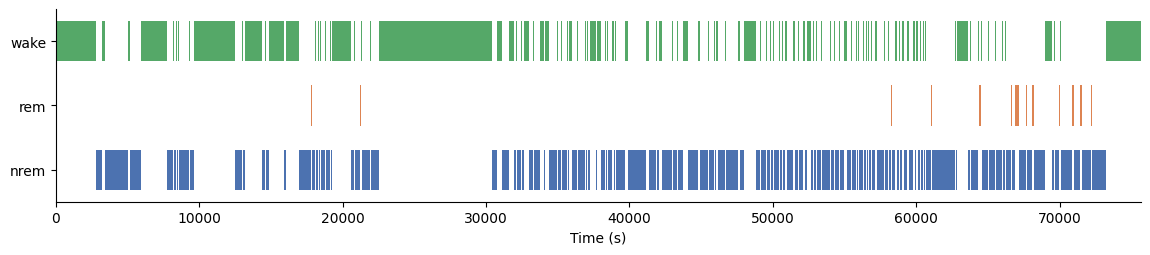

In [5]:
from nrem_sc.constants import PROCESSED_DATA_PATH
from nrem_sc.utils import plot_intervals

import numpy as np
import pynapple as nap

from replay_trajectory_classification import (
    SortedSpikesClassifier,
    Environment,
    RandomWalk,
    Uniform,
    Identity,
    DiagonalDiscrete,
    make_track_graph,
)

unit_id = '119b'
STATE_PROB = 0.99
STATE_NAMES = ["continuous", "fragmented", "stationary"]

def get_environment(num_nodes: int = 360, place_bin_size: float = 1.0):
    radius = 180 / np.pi
    angle = np.linspace(2 * np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    n_nodes = len(track_graph.nodes)
    edge_order = np.stack(
        (np.roll(np.arange(n_nodes - 1, -1, -1), 1),
         np.arange(n_nodes - 1, -1, -1)),
        axis=1,
    )

    return Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=0,
    )

# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

plot_intervals(sessions, column='label')
plot_intervals(sleep_states, column='state')

In [2]:
def fit_classifier(
    hd_spikes,
    hd_angle,
    train_ep: nap.IntervalSet,
    bin_size_ms: int = 2,
    place_bin_size: float = 1.0,
):
    """Fit the classifier on wake training data and return it."""
    spikes = (
        hd_spikes.count(bin_size=bin_size_ms, ep=train_ep, time_units="ms")
        .astype(np.bool_)
    )
    angle = hd_angle.bin_average(
        bin_size=bin_size_ms, ep=train_ep, time_units="ms"
    ).to_numpy()

    # Build classifier
    environment = get_environment(place_bin_size=place_bin_size)
    continuous_transition_types = [
        [RandomWalk(movement_var=2.0), Uniform(), Identity()],
        [Uniform(),                    Uniform(), Uniform()],
        [RandomWalk(movement_var=2.0), Uniform(), Identity()],
    ]
    classifier = SortedSpikesClassifier(
        environments=environment,
        continuous_transition_types=continuous_transition_types,
        discrete_transition_type=DiagonalDiscrete(STATE_PROB),
    )
    
    # Fit classifier
    classifier.fit(angle, spikes.to_numpy())
    return classifier


In [3]:
classifier = fit_classifier(hd_spikes, hd_angle, hd_angle.time_support)

ValueError: assignment destination is read-only

In [ ]:
t_a, t_b = 34000, 36000
epoch = nap.IntervalSet(start=[t_a], end=[t_b])

def decode_epoch(classifier, hd_spikes, epoch):
bin_size_ms = 2

spike_counts = (
    hd_spikes.restrict(epoch)
    .count(bin_size=bin_size_ms, time_units="ms")
    .astype(np.bool_)
)

decoded = classifier.predict(
    spike_counts.values,
    time=spike_counts.times(),
    state_names=STATE_NAMES,
)

prob_state = decoded.acausal_posterior.sum(dim="position").to_numpy()
posterior  = decoded.acausal_posterior.sum(dim="state")
pos_max    = posterior.idxmax(dim="position").to_numpy()

combined = np.column_stack([prob_state, pos_max])

result_df = nap.TsdFrame(t=decoded["time"].to_numpy(), d=combined, columns=STATE_NAMES + ["position"],)

SAVE_DIR = PROCESSED_DATA_PATH / unit_id / "decoded"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
result_df.save(SAVE_DIR / f"decoded{t_a}_{t_b}.npz")

  0%|          | 0/81 [00:00<?, ?it/s]

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:210: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  discrete_state_transition[state_k, state_k_1]


In [54]:
sessions[sessions["label"] == "homecage"][1]['end'] - sessions[sessions["label"] == "homecage"][1]['start']

array([39865.1072])

In [47]:
t_window = 2000

for session in sessions[sessions["label"] == "homecage"]:
    start, end = session["start"].item(), session["end"].item()
    print(f"Homecage session: {start} - {end}")
    starts = np.arange(start, end, t_window)
    for t_a in starts:
        t_b = t_a + t_window
        t_b = np.min([t_b, end])
        print(f"Decoding interval: {t_a} - {t_b}")
        print(f"Duration: {t_b - t_a:.2f} s")

Homecage session: 1551.34725 - 16644.51845
Decoding interval: 1551.34725 - 3551.34725
Duration: 2000.00 s
Decoding interval: 3551.34725 - 5551.34725
Duration: 2000.00 s
Decoding interval: 5551.34725 - 7551.34725
Duration: 2000.00 s
Decoding interval: 7551.347249999999 - 9551.347249999999
Duration: 2000.00 s
Decoding interval: 9551.347249999999 - 11551.347249999999
Duration: 2000.00 s
Decoding interval: 11551.347249999999 - 13551.347249999999
Duration: 2000.00 s
Decoding interval: 13551.347249999999 - 15551.347249999999
Duration: 2000.00 s
Decoding interval: 15551.347249999999 - 16644.51845
Duration: 1093.17 s
Homecage session: 22244.24345 - 62109.35065
Decoding interval: 22244.24345 - 24244.24345
Duration: 2000.00 s
Decoding interval: 24244.24345 - 26244.24345
Duration: 2000.00 s
Decoding interval: 26244.24345 - 28244.24345
Duration: 2000.00 s
Decoding interval: 28244.24345 - 30244.24345
Duration: 2000.00 s
Decoding interval: 30244.24345 - 32244.24345
Duration: 2000.00 s
Decoding inter